In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
# import warnings
# warnings.filterwarnings("ignore", category=FutureWarning)


In [2]:
# df = pd.read_spss(r"C:\Users\USER\Downloads\D00224_2\data.sav")
# df.to_csv('Dataset.csv', encoding='utf-8-sig', index=False)
df = pd.read_csv(r"C:\Users\User\Documents\GitHub\psychic-spoon\0 2025資料科學漫步\Dataset.csv")
df = df[df['rq21a'] == '答對'].reset_index(drop=True) # 篩選有效樣本中的注意力題答對的樣本
df.shape

(685, 211)

---
---
## 基本資料

In [3]:
individual = df.iloc[:,4:10]
individual['q3'] = individual['q3'].str.replace(r'^\(\d+\)', '', regex=True)
individual['q4'] = individual['q4'].str.replace(r'^\(\d+\)', '', regex=True)

rename_ = {'q1':'性別', 'q2':'出生年','q3':'出生縣市', 'q4':'學歷'}
individual = individual.rename(columns=rename_).drop(columns=['q3_other', 'q4_88_text'])
individual.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   性別      685 non-null    object 
 1   出生年     685 non-null    float64
 2   出生縣市    685 non-null    object 
 3   學歷      685 non-null    object 
dtypes: float64(1), object(3)
memory usage: 21.5+ KB


## 網路使用行為

In [4]:
internet_usage = df.iloc[:,11:59]

internet_usage['q6'] = np.round((internet_usage['q6_h'] + internet_usage['q6_m']/60), 4)
internet_usage['q7'] = np.round((internet_usage['q7_h'] + internet_usage['q7_m']/60), 4)
cols =  internet_usage.columns.tolist()
i ,j = cols.index('q6_h'), cols.index('q6')
cols[i], cols[j] = cols[j], cols[i]
i ,j = cols.index('q6_m'), cols.index('q7')
cols[i], cols[j] = cols[j], cols[i]
internet_usage = internet_usage[cols].drop(columns=['q6_h', 'q6_m', 'q7_h', 'q7_m'])

internet_usage_col_replace = {
                        'q8_1': '(01)維繫友誼與他人保持聯絡(傳LINE、滑臉書等)',
                        'q8_2': '(02)娛樂消遣(玩遊戲、看卡通動漫、看電影、戲劇、看直播、聽音樂、交友軟體、追星、命理占卜、打發時間、無聊)',
                        'q8_3': '(03)獲得時事/新聞/政府資訊(搜尋關鍵字、看新聞、看政府資訊、天氣資訊)',
                        'q8_4': '(04)獲得生活休閒資訊(美食、觀光旅遊、醫療衛生保健、家庭生活、親子婚姻關係、交通資訊)',
                        'q8_5': '(05)理財消費購物(看理財資訊、網路購物、理財管理、繳費、財經股市)',
                        'q8_6': '(06)學習或工作(有支薪)(語言學習、線上課程、使用文書處理軟體、學習各種軟體)',    
                        
                        'q9_1': '(01)LINE',
                        'q9_2': '(02)Facebook Messenger(臉書聊天室)',
                        'q9_3': '(03)微信Wechat',
                        'q9_4': '(04)WhatsApp',
                        'q9_5': '(05)Hangouts',
                        'q9_6': '(06)Skype',
                        'q9_7': '(07)Facetime',
                        'q9_8': '(08)Telegram',
                        'q9_88': '(88)其他',

                        'q10_1': '(01)臉書(Facebook)',
                        'q10_2': '(02)Instagram',
                        'q10_3': '(03)推特(Twitter)',
                        'q10_4': '(04)LinkedIn',
                        'q10_5': '(05)微博',
                        'q10_6': '(06)噗浪(Plurk)',
                        'q10_7': '(07)抖音(TikTok)',
                        'q10_8': '(08)PTT',
                        'q10_9': '(09)Dcard',
                        'q10_10': '(10)Pinterest',
                        'q10_88': '(88)其他',

                        'q11_1': '(01)YouTube',
                        'q11_2': '(02)愛奇藝',
                        'q11_3': '(03)Netflix 網飛',
                        'q11_4': '(04)KKTV',
                        'q11_5': '(05)LINE TV',
                        'q11_6': '(06)Li TV',
                        'q11_7': '(07)Twitch',
                        'q11_8': '(08)friDay影音',
                        'q11_88': '(88)其他'
                        }

def replace_(df, col_map):
    for col, text in col_map.items():
        x = df[col].replace(text, 1)
        x = x.infer_objects(copy=False)
        x = x.fillna(0)
        df[col] = x.astype(int)
replace_(internet_usage, internet_usage_col_replace)

rename_ = {'q5_1':'每週平均上網天數',
           'q6':'一天因工作或課業上網小時','q7':'一天因其他所需上網小時',
           'q8_1':'因維繫友誼與他人保持聯絡上網', 'q8_2':'因娛樂消遣上網', 'q8_3':'因獲得時事/新聞/政府資訊上網', 'q8_4':'因獲得生活休閒資訊上網', 'q8_5':'因理財消費購物上網', 'q8_6':'因學習或工作上網',
           'q9_1':'最近一個月使用line', 'q9_2':'最近一個月使用Messenger(臉書聊天室)', 'q9_3':'最近一個月使用微信Wechat', 'q9_4':'最近一個月使用WhatsApp', 'q9_5':'最近一個月使用Hangouts', 'q9_6':'最近一個月使用Skype', 'q9_7':'最近一個月使用Facetime', 'q9_8':'最近一個月使用Telegram', 'q9_88':'最近一個月使用其他即時通訊軟體',
           'q10_1':'最近一個月使用臉書(Facebook)', 'q10_2':'最近一個月使用Instagram', 'q10_3':'最近一個月使用推特(Twitter)', 'q10_4':'最近一個月使用LinkedIn', 'q10_5':'最近一個月使用微博', 'q10_6':'最近一個月使用噗浪(Plurk)', 'q10_7':'最近一個月使用抖音(TikTok)', 'q10_8':'最近一個月使用PTT', 'q10_9':'最近一個月使用Dcard', 'q10_10':'最近一個月使用Pinterest', 'q10_88':'最近一個月使用其他社群媒體',
           'q11_1':'最近一個月使用YouTube', 'q11_2':'最近一個月使用)愛奇藝', 'q11_3':'最近一個月使用Netflix 網飛', 'q11_4':'最近一個月使用KKTV', 'q11_5':'最近一個月使用LINE TV', 'q11_6':'最近一個月使用Li TV', 'q11_7':'最近一個月使用Twitch', 'q11_8':'最近一個月使用friDay影音', 'q11_88':'最近一個月使用其他影音平台'}
internet_usage = internet_usage.rename(columns=rename_).drop(columns=['q8_88', 'q8_88_text', 'q8_90', 'q9_88_text', 'q9_90', 'q10_88_text', 'q10_90', 'q11_88_text', 'q11_90'])
internet_usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 37 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   一天因工作或課業上網小時             685 non-null    float64
 1   一天因其他所需上網小時              685 non-null    float64
 2   因維繫友誼與他人保持聯絡上網           685 non-null    int32  
 3   因娛樂消遣上網                  685 non-null    int32  
 4   因獲得時事/新聞/政府資訊上網          685 non-null    int32  
 5   因獲得生活休閒資訊上網              685 non-null    int32  
 6   因理財消費購物上網                685 non-null    int32  
 7   因學習或工作上網                 685 non-null    int32  
 8   最近一個月使用line              685 non-null    int32  
 9   最近一個月使用Messenger(臉書聊天室)  685 non-null    int32  
 10  最近一個月使用微信Wechat          685 non-null    int32  
 11  最近一個月使用WhatsApp          685 non-null    int32  
 12  最近一個月使用Hangouts          685 non-null    int32  
 13  最近一個月使用Skype             685 non-null    int32  
 14  最近一個月使用Facetime          6

---
---

## 網路攻擊行為

- 'q22_01_1':'多常在網路上看到別人留言髒話/不好聽的話'
- 'q22_02_1':'多常在網路上看別人兇激怒他的人'
- 'q22_03_1':'多常在網路上看到別人罵討厭他的人'
- 'q22_04_1':'多常在網路上看到別人開不雅玩笑'
- 'q22_05_1':'多常在網路上看到別人用諷刺方式回覆他人',
- 'q23_01_1':'多常在網路上留言髒話/不好聽的話'
- 'q23_02_1':'多常在網路上兇激怒你的人'
- 'q23_03_1':'多常在網路上罵討厭你的人'
- 'q23_04_1':'多常在網路上開不雅玩笑'
- 'q23_05_1':'多常在網路上用諷刺方式回覆他人'

In [5]:
internet_attack = df.iloc[:, 156:166]

times_score = {'從來沒有':1, '很少':2, '有時':3, '經常':4}
times_cols = ['q22_01_1', 'q22_02_1', 'q22_03_1', 'q22_04_1', 'q22_05_1',
              'q23_01_1', 'q23_02_1', 'q23_03_1', 'q23_04_1', 'q23_05_1']
for col in times_cols:
    internet_attack[col] = pd.to_numeric(internet_attack[col].replace(times_score))
    
# rename_ = {'q22_01_1':'多常在網路上看到別人留言髒話/不好聽的話', 'q22_02_1':'多常在網路上看別人兇激怒他的人', 'q22_03_1':'多常在網路上看到別人罵討厭他的人', 'q22_04_1':'多常在網路上看到別人開不雅玩笑', 'q22_05_1':'多常在網路上看到別人用諷刺方式回覆他人',
#            'q23_01_1':'多常在網路上留言髒話/不好聽的話', 'q23_02_1':'多常在網路上兇激怒你的人', 'q23_03_1':'多常在網路上罵討厭你的人', 'q23_04_1':'多常在網路上開不雅玩笑', 'q23_05_1':'多常在網路上用諷刺方式回覆他人'}
# internet_attack = internet_attack.rename(columns=rename_)
internet_attack.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   q22_01_1  685 non-null    int64
 1   q22_02_1  685 non-null    int64
 2   q22_03_1  685 non-null    int64
 3   q22_04_1  685 non-null    int64
 4   q22_05_1  685 non-null    int64
 5   q23_01_1  685 non-null    int64
 6   q23_02_1  685 non-null    int64
 7   q23_03_1  685 non-null    int64
 8   q23_04_1  685 non-null    int64
 9   q23_05_1  685 non-null    int64
dtypes: int64(10)
memory usage: 53.6 KB


---
---

## 網路攻擊接受度

In [6]:
internet_attack_accepted = pd.concat([df.iloc[:, 147:149], df.iloc[:, 171:175]], axis=1)

acceptance_score = {'可以接受':5, '稍微可以接受':4, '普通':3, '有點不可以接受':2,'不可以接受':1}
acceptance_cols = ['q20_01_1', 'q20_02_1',
                   'q25_01_1', 'q25_02_1', 'q25_03_1', 'q25_04_1']

for col in acceptance_cols:
    internet_attack_accepted[col] = pd.to_numeric(internet_attack_accepted[col].replace(acceptance_score))

rename_ = {'q20_01_1':'在網路上謾罵討厭的人使其知道他不屬於您的團體', 'q20_02_1':'為了獲得想要的而在網路上謾罵他人',
           'q25_01_1':'在網路上對與您意見不同的人講挑釁的話', 'q25_02_1':'在網路上對討論政治話題的人講挑釁的話', 'q25_03_1':'在網路上對攻擊您看法的人謾罵', 'q25_04_1':'在網路上對與您意見不同的人謾罵'}
internet_attack_accepted = internet_attack_accepted.rename(columns=rename_)
internet_attack_accepted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   在網路上謾罵討厭的人使其知道他不屬於您的團體  685 non-null    int64
 1   為了獲得想要的而在網路上謾罵他人        685 non-null    int64
 2   在網路上對與您意見不同的人講挑釁的話      685 non-null    int64
 3   在網路上對討論政治話題的人講挑釁的話      685 non-null    int64
 4   在網路上對攻擊您看法的人謾罵          685 non-null    int64
 5   在網路上對與您意見不同的人謾罵         685 non-null    int64
dtypes: int64(6)
memory usage: 32.2 KB


---
---

## 心理幸福感/生活品質

In [7]:
happiness = pd.concat([df.iloc[:, 140:141], df.iloc[:, -13:-9]], axis=1)

satisfy_score = {'非常滿意':5, '滿意':4, '普通':3, '不滿意':2,'非常不滿意':1}
satisfy_cols = ['q15_03_1', 'q38_01_1', 'q38_02_1']
for col in satisfy_cols:
    happiness[col] = pd.to_numeric(happiness[col].replace(satisfy_score))

happy_score = {'非常快樂':5, '快樂':4, '普通':3, '不快樂':2,'非常不快樂':1}
happy_cols = ['q39_1']
for col in happy_cols:
    happiness[col] = pd.to_numeric(happiness[col].replace(happy_score))

fill_na_cols = ['q15_03_1', 'q38_01_1', 'q38_02_1', 'q39_1']
for col in fill_na_cols:
    happiness[col] = happiness[col].fillna(happiness[col].max()).astype(int)
    
rename_ = {'q15_03_1':'對於政府目前處理疫情的滿意程度', 'q38_01_1':'對於生活的滿意程度',
           'q38_02_1':'對於目前台灣社會的滿意程度', 'q39_1':'對於目前日子的快樂程度'}
happiness = happiness.rename(columns=rename_)
happiness.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   對於政府目前處理疫情的滿意程度  685 non-null    int32 
 1   q37a             685 non-null    object
 2   對於生活的滿意程度        685 non-null    int32 
 3   對於目前台灣社會的滿意程度    685 non-null    int32 
 4   對於目前日子的快樂程度      685 non-null    int32 
dtypes: int32(4), object(1)
memory usage: 16.2+ KB


---
---


## 網路抵制

In [8]:
cancel_culture = pd.concat([df.iloc[:, 178:192], df.iloc[:, 195:197]], axis=1)

want_score = {'非常不想':1, '不想':2, '普通':3, '想':4, '非常想':5}
cancel_culture['q27_1'] = pd.to_numeric(cancel_culture['q27_1'].replace(want_score)).fillna(pd.to_numeric(cancel_culture['q27_1'].replace(want_score)).max()).astype(int)

effect_score = {'完全沒有效':1, '沒有效':2, '普通':3, '有效':4, '非常有效':5}
cancel_culture['q30_1'] = pd.to_numeric(cancel_culture['q30_1'].replace(effect_score)).fillna(pd.to_numeric(cancel_culture['q30_1'].replace(effect_score)).max()).astype(int)

cost_score = {'非常少':1, '有點少':2, '普通':3, '有點多':4, '非常多':5}
cancel_culture['q34_1'] = pd.to_numeric(cancel_culture['q34_1'].replace(cost_score)).fillna(pd.to_numeric(cancel_culture['q34_1'].replace(cost_score)).max()).astype(int)

cost_score = {'非常少':1, '有點少':2, '普通':3, '有點多':4, '非常多':5}
cancel_culture['q35_1'] = pd.to_numeric(cancel_culture['q35_1'].replace(cost_score)).fillna(pd.to_numeric(cancel_culture['q35_1'].replace(cost_score)).max()).astype(int)

cancel_culture_col_replace = {
                        'q28_1': '(01)取消關注他們的粉專或帳號',
                        'q28_2': '(02)拒絕觀看他們的發文或影音',
                        'q28_3': '(03)在網路上留言或發文指責他們',
                        'q28_4': '(04)其他',
                        'q28_5': '(05)沒有做過上述的抵制行為(跳答至37a題 )',
                        
                        'q29_1': '(01)歧視特定國家、種族或性別',
                        'q29_2': '(02)有不同的政治意識型態或價值觀',
                        'q29_3': '(03)不表態支持重要的社會議題',
                        'q29_4': '(04)做出不道德、不正當或不合法行為',
                        'q29_5': '(05)其他'
                        }

def replace_(df, col_map):
    for col, text in col_map.items():
        x = df[col].replace(text, 1)
        x = x.infer_objects(copy=False)
        x = x.fillna(0)
        df[col] = x.astype(int)
replace_(cancel_culture, cancel_culture_col_replace)

rename_ = {'q27_1':'多想透過社群媒體抵制言行不當的名人', 
           'q28_1':'取消關注他們的粉專或帳號抵制言行不當的名人', 'q28_2':'拒絕觀看他們的發文或影音抵制言行不當的名人', 'q28_3':'在網路上留言或發文指責言行不當的名人', 'q28_4':'其他抵制言行不當的名人', 'q28_5':'您沒有做過上述的抵制行為',
           'q29_1':'因名人歧視特定國家、種族或性別而抵制名人', 'q29_2':'因有不同的政治意識型態或價值觀而抵制名人', 'q29_3':'因不表態支持重要的社會議題而抵制名人', 'q29_4':'因做出不道德、不正當或不合法行為而抵制名人', 'q29_5':'因其他而抵制名人',
           'q30_1':'使名人改善其行為而透過社群媒體抵制的效果', 'q34_1':'社群媒體抵制對您的損失', 'q35_1':'過去與您參與社群媒體抵制的人數'}
cancel_culture = cancel_culture.rename(columns=rename_).drop(columns=['q28_4_text', 'q29_5_text'])
cancel_culture.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   多想透過社群媒體抵制言行不當的名人      685 non-null    int32
 1   取消關注他們的粉專或帳號抵制言行不當的名人  685 non-null    int32
 2   拒絕觀看他們的發文或影音抵制言行不當的名人  685 non-null    int32
 3   在網路上留言或發文指責言行不當的名人     685 non-null    int32
 4   其他抵制言行不當的名人            685 non-null    int32
 5   您沒有做過上述的抵制行為           685 non-null    int32
 6   因名人歧視特定國家、種族或性別而抵制名人   685 non-null    int32
 7   因有不同的政治意識型態或價值觀而抵制名人   685 non-null    int32
 8   因不表態支持重要的社會議題而抵制名人     685 non-null    int32
 9   因做出不道德、不正當或不合法行為而抵制名人  685 non-null    int32
 10  因其他而抵制名人               685 non-null    int32
 11  使名人改善其行為而透過社群媒體抵制的效果   685 non-null    int32
 12  社群媒體抵制對您的損失            685 non-null    int32
 13  過去與您參與社群媒體抵制的人數        685 non-null    int32
dtypes: int32(14)
memory usage: 37.6 KB


---
---

## 政黨極化

       count       mean        std  min   25%   50%   75%    max
q40_1  685.0  37.055474  25.952157  0.0  11.0  40.0  50.0  100.0
q41_1  685.0  41.557664  25.799581  0.0  20.0  50.0  60.0  100.0


<Axes: xlabel='q40_1', ylabel='q41_1'>

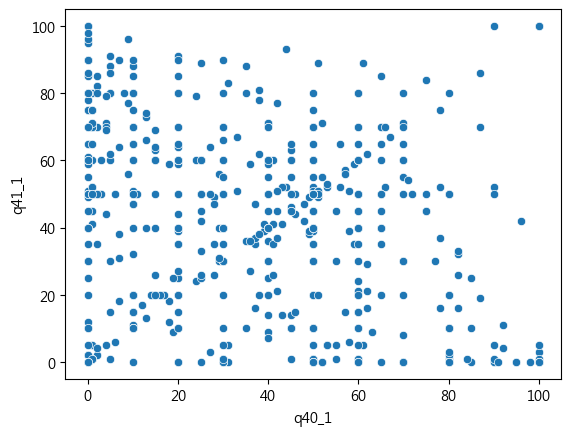

In [91]:
political_party = df.iloc[:, -9:-7]
for col in ['q40_1', 'q41_1']:
    political_party[col]= political_party[col].replace({'非常冰冷':0, '非常溫暖':100}).astype(float)
# political_party = political_party.rename(columns={'q40_1':'國民黨溫暖程度', 'q41_1':'民進黨溫暖程度'})
# political_party.info()
political_party['q40_1']= political_party['q40_1'].replace('非常冰冷', 0)
political_party['q40_1']= political_party['q40_1'].replace('非常溫暖', 100)
political_party['q41_1']= political_party['q41_1'].replace('非常冰冷', 0)
political_party['q41_1']= political_party['q41_1'].replace('非常溫暖', 100)
political_party['q40_1']= pd.to_numeric(political_party['q40_1'])
political_party['q41_1']= pd.to_numeric(political_party['q41_1'])
print(political_party.describe().T)
sns.scatterplot(data=political_party, x='q40_1', y='q41_1')

In [86]:
from scipy import stats

t_stat, p_value = stats.ttest_rel(political_party['q40_1'], political_party['q41_1'])
different = political_party['q40_1']-political_party['q41_1']
mean_q40 = political_party['q40_1'].mean()
mean_q41 = political_party['q41_1'].mean()
mean_different = different.mean()
std_different = different.std(ddof=1)
cohen_d = mean_different/std_different if std_different != 0 else np.nan

print(f"N = {len(political_party)}")
print(f"Mean(Q40_1 國民黨溫度) = {mean_q40:.4f}")
print(f"Mean(Q41_1 民進黨溫度) = {mean_q41:.4f}")
print(f"Mean difference (Q41_1 - Q40_1) = {mean_different:.4f}")
print(f"t = {t_stat:.3f}, p = {p_value:.6f}, 小於0.05有顯著")
print(f"Cohen's dz (paired) = {cohen_d:.4f}")

N = 685
Mean(Q40_1 國民黨溫度) = 37.0555
Mean(Q41_1 民進黨溫度) = 41.5577
Mean difference (Q41_1 - Q40_1) = -4.5022
t = -2.998, p = 0.002819, 小於0.05有顯著
Cohen's dz (paired) = -0.1145


           N  mean_q40  mean_q41  mean_diff
cluster                                    
0        106     68.45      9.50     -58.95
1        281     51.38     52.03       0.65
2        154      9.92     68.12      58.20
3        144     15.02     16.31       1.29


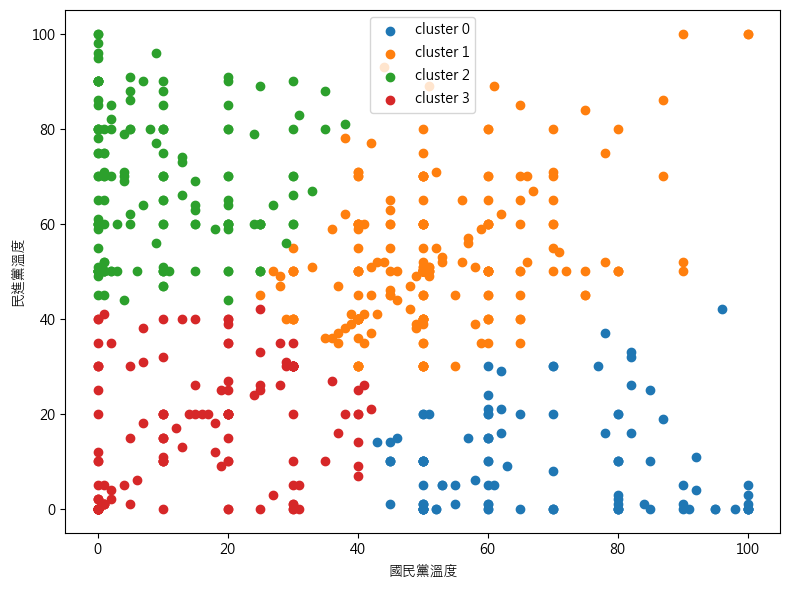

各群均值：
           q40_1    q41_1
cluster                  
0        68.4528   9.5000
1        51.3772  52.0320
2         9.9156  68.1169
3        15.0208  16.3125


In [92]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
X = political_party.to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
political_party = political_party.assign(cluster=labels)

cluster_summary = (political_party.groupby("cluster").agg(N=("cluster", "size"),
                                                          mean_q40=("q40_1", "mean"),
                                                          mean_q41=("q41_1", "mean"),)
                                                          .assign(mean_diff=lambda d: d["mean_q41"]-d["mean_q40"]).sort_values("cluster"))
print(cluster_summary.round(2))

plt.figure(figsize=(8, 6))
for c in range(4):
    idx = political_party["cluster"] == c
    plt.scatter(political_party.loc[idx, "q40_1"], political_party.loc[idx, "q41_1"], label=f"cluster {c}")
plt.xlabel("國民黨溫度")
plt.ylabel("民進黨溫度")
plt.legend()
plt.tight_layout()
plt.show()

# political_party['cluster'] = political_party['cluster'].replace({0:'親藍', 1:'雙重認同', 2:'親綠', 3:'雙重冷感'})

cluster_means = political_party.groupby("cluster")[['q40_1', 'q41_1']].mean()
print("各群均值：")
print(cluster_means.round(4))



In [93]:
from scipy import stats
anova_q40 = stats.f_oneway(*(political_party.loc[political_party["cluster"]==g, "q40_1"] for g in range(4)))
anova_q41 = stats.f_oneway(*(political_party.loc[political_party["cluster"]==g, "q41_1"] for g in range(4)))
print("\nANOVA 結果：")
print(f"Q40_1 國民黨溫度: F={anova_q40.statistic:.3f}, p={anova_q40.pvalue:.6f}")
print(f"Q41_1 民進黨溫度: F={anova_q41.statistic:.3f}, p={anova_q41.pvalue:.6f}")



ANOVA 結果：
Q40_1 國民黨溫度: F=680.731, p=0.000000
Q41_1 民進黨溫度: F=670.799, p=0.000000


---
---


## 敘述統計

In [ ]:
full_data = pd.concat([])

---
---

## 分析

### 信效度分析
- 題目鑑別度
- 題目與整體的概念一致性
- 題目對整體信度的貢獻（拉高還是拉低整體內部一致性）

[Cronbach alpha](https://en.wikipedia.org/wiki/Cronbach%27s_alpha)

In [ ]:
from scipy.stats import ttest_ind

def cronbach_alpha(df_items: pd.DataFrame) -> float:
    """ df_items 為 n×k 的題目得分資料框 """
    k = df_items.shape[1]                       # 題目數 k
    item_var = df_items.var(ddof=1, axis=0)     # 各題變異數 σ_i^2
    total_var = df_items.sum(axis=1).var(ddof=1)  # 總分變異數 σ_T^2
    alpha = (k / (k - 1)) * (1 - item_var.sum() / total_var)
    return alpha

internet_attack_cols = ['q22_01_1', 'q22_02_1', 'q22_03_1', 'q22_04_1', 'q22_05_1', 'q23_01_1', 'q23_02_1', 'q23_03_1', 'q23_04_1', 'q23_05_1']
internet_attack['total'] = internet_attack[internet_attack_cols].sum(axis=1)
n_ext = int(len(internet_attack)*.27)
high = internet_attack.nlargest(n_ext, 'total')
low = internet_attack.nsmallest(n_ext, 'total')

rows = []
alpha_full = cronbach_alpha(internet_attack[internet_attack_cols])

for i in internet_attack_cols:
    t_stat, p_value = ttest_ind(high[i], low[i], nan_policy='omit')
    ri = internet_attack[i].corr(internet_attack['total'] - internet_attack[i])
    alpha_del = cronbach_alpha(internet_attack[[col for col in internet_attack_cols if col != i]])

    rows.append([i, round(t_stat, 2), round(p_value, 4), round(ri, 4), round(alpha_del, 4)])

result = (pd.DataFrame(rows, columns=['col', 't', 'p', 'ri', 'alpha_del']).assign(flag = lambda d:
                                                                                  ((d['t']<3)&(d['p']>=.05)) |
                                                                                  (d['ri']<.30) |
                                                                                  (d['alpha_del']>alpha_full)))

print(result)

from scipy.stats import f
def alpha_ci(alpha, n, k, conf_level=.95):
    """Feldt, Woodruff & Salih (1987) CI for alpha"""
    df1 = n-1
    df2 = (n-1)*(k-1)
    alpha_half = (1-conf_level)/2

    f_lower = f.ppf(1-alpha_half, df1, df2)
    f_upper = f.ppf(alpha_half, df1, df2)

    lower = 1-((1-alpha)*f_lower)
    upper = 1-((1-alpha)*f_upper)

    return lower, upper
n, k = internet_attack.shape[0], len(internet_attack_cols)
ci_low, ci_up = alpha_ci(alpha_full, n, k)
print('-------------------------------------------------')
print(f'信度分析: Cronbach α = {alpha_full:.6f}  (95% CI: {ci_low:.4f} – {ci_up:.4f})')


        col      t    p      ri  alpha_del   flag
0  q22_01_1  24.92  0.0  0.6439     0.8354  False
1  q22_02_1  25.02  0.0  0.6851     0.8313  False
2  q22_03_1  26.94  0.0  0.6756     0.8322  False
3  q22_04_1  25.85  0.0  0.6318     0.8366  False
4  q22_05_1  24.84  0.0  0.6288     0.8368  False
5  q23_01_1  13.21  0.0  0.4603     0.8509  False
6  q23_02_1  13.66  0.0  0.4725     0.8500  False
7  q23_03_1  13.91  0.0  0.4904     0.8487  False
8  q23_04_1  10.96  0.0  0.4084     0.8544  False
9  q23_05_1  15.50  0.0  0.4912     0.8489  False
-------------------------------------------------
信度分析: Cronbach α = 0.856443  (95% CI: 0.8399 – 0.8720)


[Confidence interval for Cronbach's Alpha](https://search.r-project.org/CRAN/refmans/cocron/html/cronbach.alpha.CI.html)

#### KMO值, Bartelett's test
- 判斷是否適合做 探索性因素分析 (EFA)／主成分分析 (PCA)

In [ ]:
from factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
kmo_all, kmo_model = calculate_kmo(internet_attack[internet_attack_cols])
print(f'KMO = {kmo_model:.4f}')
chi2, p = calculate_bartlett_sphericity(internet_attack[internet_attack_cols])
print(f"'Bartlett's chi2 = {chi2:.2f}, p = {p:.4f}")

KMO = 0.8761
'Bartlett's chi2 = 3296.55, p = 0.0000


- ≥ .90 → Marvelous (極佳)
- .80–.89 → Meritorious
- .70–.79 → Middling
- .60–.69 → Mediocre
- .50–.59 → Miserable
- < .50 → Unacceptable → 不建議做 EFA（探索性因子分析）

#### PCA

   Component  Eigenvalue  Prop.Var  Cum.Prop
0          1      2.3251    0.4840    0.4840
1          2      0.8993    0.1872    0.6711
2          3      0.2813    0.0586    0.7297
3          4      0.2463    0.0513    0.7810
4          5      0.2183    0.0454    0.8264


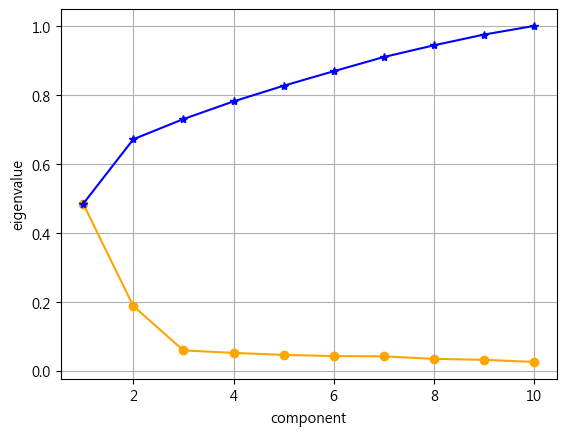

        PC1       PC2
0 -2.554384  0.115013
1  0.782425 -1.236406
2  0.753885 -1.253810
3  3.599194  3.338770
4  0.119025 -0.413583


In [ ]:
from sklearn.decomposition import PCA
X = internet_attack.drop(columns=['total']).values
pca = PCA(n_components=len(internet_attack_cols)).fit(X)
eigenvalues = pca.explained_variance_
eigenvalues_ratio = pca.explained_variance_ratio_
cum_eigenvalues = eigenvalues_ratio.cumsum()

eig_table = pd.DataFrame({'Component': np.arange(1, len(eigenvalues)+1),'Eigenvalue': np.round(eigenvalues, 4),'Prop.Var': np.round(eigenvalues_ratio, 4),'Cum.Prop': np.round(cum_eigenvalues, 4)})
print(eig_table.head(5))

plt.plot(range(1, len(eigenvalues_ratio)+1), eigenvalues_ratio, marker='o', color='orange')
plt.plot(range(1, len(cum_eigenvalues)+1), cum_eigenvalues, marker='*', color='b')
plt.xlabel('component')
plt.ylabel('eigenvalue')
plt.grid()
plt.show()

pca_k = PCA(n_components=2).fit(X)
loadings = pd.DataFrame(pca_k.components_.T, index=internet_attack_cols, columns=[f'PC{i+1}' for i in range(2)])

scores = pca_k.transform(X)
internet_attack_scores = pd.DataFrame(scores, columns=[f'PC{i+1}' for i in range(2)], index=internet_attack.index)
print(internet_attack_scores.head())

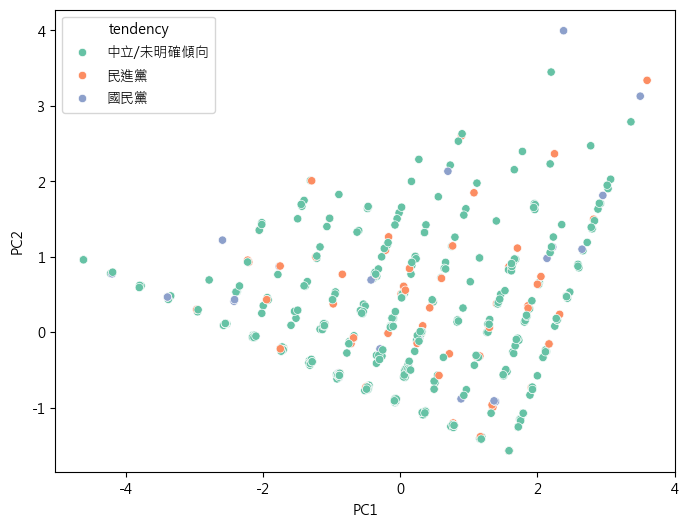

In [ ]:
df_some = pd.concat([internet_attack_scores, political_party['tendency']], axis=1)
plt.figure(figsize=(8, 6))
sns.scatterplot(data = df_some, x='PC1', y='PC2', hue='tendency', palette='Set2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

#### 建模 Logistic

In [ ]:
df_full = pd.concat([internet_attack, political_party['tendency']], axis=1).drop(columns=['total'])
df_full['tendency'] = df_full['tendency'].map({'民進黨':1, '國民黨':2, '中立/未明確傾向':3})

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y = df_full['tendency']

base_clf = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')

# 方案 A: 原始題
X_raw = df_full.drop(columns=['tendency'])
auc_raw = cross_val_score(base_clf, X_raw, y, cv=cv, scoring='roc_auc_ovr').mean()
# 方案 B: PC1, PC2
X_pca = internet_attack_scores[['PC1','PC2']]
auc_pca = cross_val_score(base_clf, X_pca, y, cv=cv, scoring='roc_auc_ovr').mean()

print(f"AUC (raw) = {auc_raw:.3f}")
print(f"AUC (PCA) = {auc_pca:.3f}")

AUC (raw) = 0.513
AUC (PCA) = 0.506


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.

---
---